# **Prática 3 - Caixero Viajante**
---

* Diane Fenzi Gonçalves (2019006574)
* Rubia Alice Moreira de Souza (2022043507)

A termodinâmica pode ser usa para modelar diversos tipos de problemas, que a princípio não aparetam ter relação com ela. Um deles, é o problema do caixeiro viajante, que consiste em encontrar o melhor caminho que passe por todas as cidades uma única vez e retorne a cidade inicial.

Para solucionar esse problema, podemos utilizar o método de Annealing da termodinâmica, que aliado ao algoritmo de Metrópolis e Monte Carlo, consegue chegar em aproximações muito boas em relação a solução exata.

## **Imports**
---

In [35]:
import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib.path import Path
import matplotlib.patches as patches

## **Implementação de funções auxiliares**
---

### **Criar vetor de cidades aleatório**
---

Primeiro, precisamos definir pontos aleatórios no plano para representar as cidades do problema. Abaixo temos uma implementação para gerar esses valores. Este trecho gera dois vetores para representar as posições X e Y dos pontos em um plano nos valores entre 0 e 1:


In [36]:
def criarVetorCidades(
    quantidadeCidades: int
  ) -> tuple[list[float], list[float]]:

  posicoesX = np.random.random(quantidadeCidades)
  posicoesY = np.random.random(quantidadeCidades)

  return (posicoesX, posicoesY)

In [100]:
def testeCriarCidades() -> None:
  (posicoesX, posicoesY) = criarVetorCidades(5)
  print("[LOG]: Teste para criação do vetor de cidades aleatórias")
  print("Posição X \t\t Posição Y")
  for x, y in zip(posicoesX, posicoesY):
    print(f"{x} \t {y}")

testeCriarCidades()

[LOG]: Teste para criação do vetor de cidades aleatórias
Posição X 		 Posição Y
0.9576015173048573 	 0.9977841626678368
0.2312312148175647 	 0.36108564906344953
0.582999841043375 	 0.2061432018792102
0.31350321160916317 	 0.9154254342686253
0.7996444123064621 	 0.7083941496511615


### **Criar tabela de distâncias**
---

Depois devemos ter formas de medir a energia de modo eficiente. Neste caso, a energia equivale ao custo de percorrer as distâncias entre os pontos.

A fim de realizar as operações mais rapidamente, podemos pre calcular as distâncias entre todos os pontos e apenas usá-las como referência no futuro.

In [38]:
def criarTabelaDistancias(
    posicoesX: list[float],
    posicoesY: list[float]
  ) -> list[list[float]]:

  tabelaDistancias: list[list[float]] = np.zeros((
    len(posicoesX), len(posicoesY)
  ))

  for i in range(len(posicoesX)):
    x1 = posicoesX[i]
    y1 = posicoesY[i]

    for j in range(len(posicoesY)):
      x2 = posicoesX[j]
      y2 = posicoesY[j]


      tabelaDistancias[i][j] = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

  return tabelaDistancias

In [39]:
def testeTabelaDistancias() -> None:
  (posicoesX, posicoesY) = criarVetorCidades(5)
  tabelaDistancias = criarTabelaDistancias(posicoesX, posicoesY)

  print("[LOG]: Teste para criação da tabela de distâncias")
  for linha in tabelaDistancias:
    print(linha)

testeTabelaDistancias()

[LOG]: Teste para criação da tabela de distâncias
[0.         0.09591395 0.84433775 0.9251738  0.81404529]
[0.09591395 0.         0.873968   0.96836314 0.79736346]
[0.84433775 0.873968   0.         0.16339784 0.40624608]
[0.9251738  0.96836314 0.16339784 0.         0.56885943]
[0.81404529 0.79736346 0.40624608 0.56885943 0.        ]


### **Criar vetor de caminho aleatório**
---

O primeiro passo para a solução de Annealing é partir de uma configuração aleatória. Então, precisamos criar um caminho inicial aleatório:

In [40]:
def criarVetorCaminho(quantidadeCidades: int) -> list[int]:
  caminho = np.arange(quantidadeCidades)
  np.random.shuffle(caminho)
  return caminho

In [41]:
def testeCriarVetorCaminho() -> None:
  caminho = criarVetorCaminho(5)
  print("[LOG]: Teste para criação do vetor de caminho")
  print(caminho)

testeCriarVetorCaminho()

[LOG]: Teste para criação do vetor de caminho
[4 1 3 0 2]


### **Calcular custo de um caminho**
---

A energia total, será equivalente a calcular toda a distância do percurso percorrido. Podemos calculá-la da seguinte forma:

In [42]:
def calcularCusto(
    distancias: list[list[float]],
    caminho: list[int]
  ) -> float:

  custo = 0
  for i in range(len(caminho) - 1):
    cidadeOrigem = caminho[i]
    cidadeDestino = caminho[i + 1]
    custo += distancias[cidadeOrigem][cidadeDestino]

  return custo

In [43]:
def testeCalcularCusto() -> None:
  quantidadeCidades = 10
  (posicoesX, posicoesY) = criarVetorCidades(quantidadeCidades)
  tabelaDistancias = criarTabelaDistancias(posicoesX, posicoesY)

  caminho = criarVetorCaminho(quantidadeCidades)
  custo = calcularCusto(tabelaDistancias, caminho)

  print("[LOG]: Teste para calcular o custo do caminho")
  print("Caminho: ", caminho)
  print("Custo: ", custo)

testeCalcularCusto()

[LOG]: Teste para calcular o custo do caminho
Caminho:  [1 5 2 9 3 4 8 7 6 0]
Custo:  5.4742717510006536


### **Permutação de um caminho**
---

Após gerar um caminho, devemos propor uma alteração aleatória nele. Para isso, selecionamos dois indices aleatórios, um para o início e outro para o fim, e realizamos uma permutação entre os dois e todos os outros que estiverem entre eles:

In [44]:
def trocarCaminho(
    caminho: list[int],
    distancias: list[list[float]]
  ) -> tuple[list[int], float]:

  def encontrarIndices(caminho: list[int]) -> tuple[int, int]:
    indiceInicio = np.random.randint(len(caminho))
    indiceFinal = np.random.randint(len(caminho))

    while indiceFinal == indiceInicio:
      indiceFinal = np.random.randint(len(caminho))

    minimo = min(indiceInicio, indiceFinal)
    maximo = max(indiceInicio, indiceFinal)

    return (minimo, maximo)

  (inicio, fim) = encontrarIndices(caminho)

  novoCaminho = np.copy(caminho)
  for i in range(len(caminho)):
    if i >= inicio and i <= fim:
      novoCaminho[i] = caminho[fim - i + inicio]

  antesModificado = inicio - 1
  if antesModificado < 0:
    antesModificado = len(caminho) - 1

  aposModificado = fim + 1
  if aposModificado >= len(caminho):
    aposModificado = 0

  deltaCusto = (
      - distancias[caminho[antesModificado]][caminho[inicio]]
      - distancias[caminho[aposModificado]][caminho[fim]]
      + distancias[novoCaminho[antesModificado]][novoCaminho[inicio]]
      + distancias[novoCaminho[aposModificado]][novoCaminho[fim]]
  )

  return novoCaminho, deltaCusto

In [45]:
def testeTrocarCaminho() -> None:
  quantidadeCidades = 10
  (posicoesX, posicoesY) = criarVetorCidades(quantidadeCidades)
  tabelaDistancias = criarTabelaDistancias(posicoesX, posicoesY)
  caminho = criarVetorCaminho(quantidadeCidades)
  (novoCaminho, deltaCusto) = trocarCaminho(caminho, tabelaDistancias)

  print("[LOG]: Teste para trocar o caminho")
  print("Caminho: ", caminho)
  print("Novo Caminho: ", novoCaminho)

testeTrocarCaminho()

[LOG]: Teste para trocar o caminho
Caminho:  [8 7 3 0 5 6 2 9 1 4]
Novo Caminho:  [0 3 7 8 5 6 2 9 1 4]


In [46]:
def plotTrocaCaminho(
    caminhoNovo: list[int],
    caminhoAntigo: list[int],
    posicoesX: list[float],
    posicoesY: list[float],
    titulo: str = 'Diferença entre caminhos'
  ) -> None:

  verticesNovos: list[tuple[float, float]] = []
  verticeAntigos: list[tuple[float, float]] = []

  for i in caminhoNovo:
    verticesNovos.append((posicoesX[i], posicoesY[i]))
  verticesNovos.append((posicoesX[caminhoNovo[0]], posicoesY[caminhoNovo[0]]))

  for i in caminhoAntigo:
    verticeAntigos.append((posicoesX[i], posicoesY[i]))
  verticeAntigos.append(
    (posicoesX[caminhoAntigo[0]], posicoesY[caminhoAntigo[0]])
  )

  codes = [Path.MOVETO] + [Path.LINETO] * (len(verticesNovos) - 1)
  pathNovo = Path(verticesNovos, codes)
  pathAntigo = Path(verticeAntigos, codes)

  fig, ax = plt.subplots()
  patchNovo = patches.PathPatch(
    pathNovo,
    edgecolor = "blue",
    facecolor = "none",
    lw = 2
  )
  patchAntigo = patches.PathPatch(
    pathAntigo,
    edgecolor = "orange",
    facecolor = "none",
    lw = 2
  )

  for i in range(len(verticesNovos)):
    ax.scatter(verticesNovos[i][0], verticesNovos[i][1], color = "black")

  ax.add_patch(patchNovo)
  ax.add_patch(patchAntigo)
  ax.set_title(titulo)
  ax.set_xlabel('X-axis')
  ax.set_ylabel('Y-axis')
  ax.grid(True)
  plt.show()

Aqui temos um exemplo de alteração proposta em um caminho aleatório gerado. Em laranja temos o caminho original. Já em azul, temos a proposta de alteração:


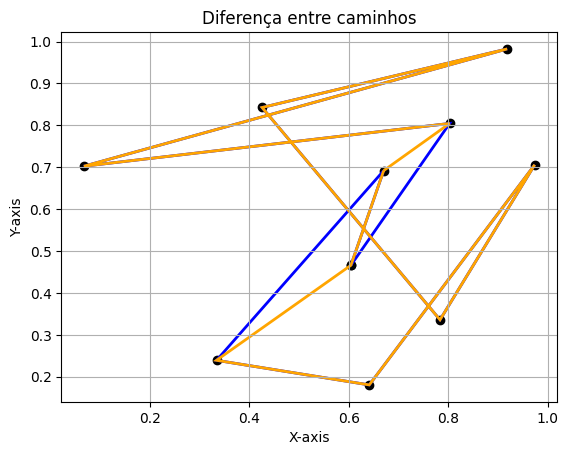

Delta Custo:  0.429530964759926


In [47]:
def testeTrocaCaminhoPlot() -> None:
  quantidadeCidades = 10
  (posicoesX, posicoesY) = criarVetorCidades(quantidadeCidades)
  tabelaDistancias = criarTabelaDistancias(posicoesX, posicoesY)
  caminho = criarVetorCaminho(quantidadeCidades)
  (novoCaminho, deltaCusto) = trocarCaminho(caminho, tabelaDistancias)

  plotTrocaCaminho(novoCaminho, caminho, posicoesX, posicoesY)
  print("Delta Custo: ", deltaCusto)

testeTrocaCaminhoPlot()

## **Implementação do método Annealing**
---

Em cada iteração, devemos tentar fazer uma alteração no caminho e verificar se ela será aceita ou não seguindo o algoritmo de Metropolis:


In [48]:
def aplicarAlgoritmoMetropolis(
    caminho: list[int],
    temperatura: float,
    tabelaDistancias: list[list[int]]
  ) -> list[int]:

  (novoCaminho, deltaCusto) = trocarCaminho(caminho, tabelaDistancias)
  beta = 1 / temperatura
  resultado = np.exp(-(deltaCusto * beta))
  numeroAleatorio = np.random.rand()

  if numeroAleatorio < resultado:
    return novoCaminho
  else:
    return caminho

Iremos tentar aplicar a modificação diversas vezes para reduzir a correlação entre as iterações e o erro:

In [49]:
def aplicarPassoMonteCarlo(
    quantidadeCidades: int,
    caminho: list[int],
    temperatura: float,
    tabelaDistancias: list[list[int]]
  ) -> list[int]:

  for i in range(quantidadeCidades):
    caminho = aplicarAlgoritmoMetropolis(
      caminho,
      temperatura,
      tabelaDistancias
    )

  return caminho

Por fim, a Solução de Annealing em si. Nela, realizamos diversas iterações e em cada uma delas temos a possibilidade de alterar aleatoriamente o caminho proposto. Nós realizamos esse procedimento enquanto o valor da temperatura é maior que um valor mínimo previamente definido. A cada iteração, devemos reduzir o valor da temperatura e tentar novamente gerar um melhor caminho.

Se aproveitando da lei dos grandes números, gradualmente nós nos aproximamos da solução ótima a cada iteração.

In [50]:
def aplicarSimulacaoAnnealing(
    posicoesX: list[int],
    posicoesY: list[int],
    temperatura: float,
    passoReducao: float,
    temperaturaMinima: float
  ) -> object:

  tabelaDistancias: list[list[float]] = criarTabelaDistancias(
    posicoesX,
    posicoesY
  )
  quantidadeCidades: int = len(posicoesX)
  caminho: list[int] = criarVetorCaminho(quantidadeCidades)
  custo: float = calcularCusto(tabelaDistancias, caminho)

  custoInicial: float = custo
  caminhoInicial: list[int] = np.copy(caminho)
  melhorCusto: float = custo
  melhorCaminho: list[int] = caminho
  quantidadePassos: int = 0
  custos: list[float] = []
  temperaturas: list[float] = []

  while temperatura > temperaturaMinima:
    caminho = aplicarPassoMonteCarlo(
      quantidadeCidades,
      caminho,
      temperatura,
      tabelaDistancias
    )

    custo = calcularCusto(tabelaDistancias, caminho)
    if custo < melhorCusto:
      melhorCusto = custo
      melhorCaminho = caminho

    custos.append(custo)
    temperaturas.append(temperatura)
    temperatura *= passoReducao
    quantidadePassos += 1

  return {
    "melhorCaminho": melhorCaminho,
    "caminhoInicial": caminhoInicial,
    "melhorCusto": melhorCusto,
    "custoInicial": custoInicial,
    "quantidadePassos": quantidadePassos,
    "custos": custos,
    "temperaturas": temperaturas
  }

In [51]:
def plotCaminho(
    caminho: list[int],
    posicoesX: list[float],
    posicoesY: list[float],
    titulo: str = 'Caminho percorrido'
  ) -> None:

  verticesNovos: list[tuple[float, float]] = []

  for i in caminho:
    verticesNovos.append((posicoesX[i], posicoesY[i]))
  verticesNovos.append((posicoesX[caminho[0]], posicoesY[caminho[0]]))

  codes = [Path.MOVETO] + [Path.LINETO] * (len(verticesNovos) - 1)
  path = Path(verticesNovos, codes)

  fig, ax = plt.subplots()
  patch = patches.PathPatch(
    path,
    edgecolor = "blue",
    facecolor = "none",
    lw = 2
  )

  for i in range(len(verticesNovos)):
    ax.scatter(verticesNovos[i][0], verticesNovos[i][1], color = "black")

  ax.add_patch(patch)
  ax.set_title(titulo)
  ax.set_xlabel('X-axis')
  ax.set_ylabel('Y-axis')
  ax.grid(True)
  plt.show()

Abaixo temos o resultado de uma simulação de Annealing. Primeiro temos o gráfico da melhor rota. Depois o gráfico da rota aleatória gerada. Por fim, vemos as alterações realizadas entre dois caminhos. Em laranja, temos o caminho original. Em azul, o caminho final.

[LOG]: Simulação com parâmetros - Cidades: 10 Temperatura: 10
Melhor Caminho:  [3 4 2 0 5 9 6 7 8 1]
Melhor Custo:  2.4753281039095327
Custo Inicial:  5.931038475213085


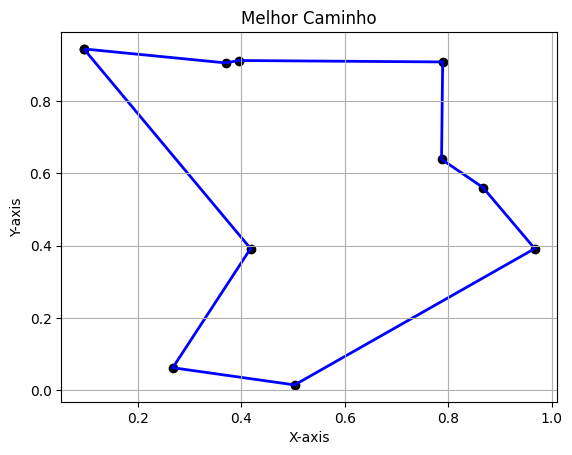

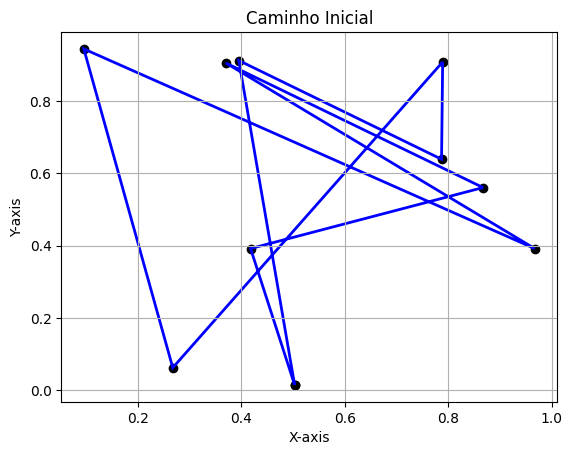

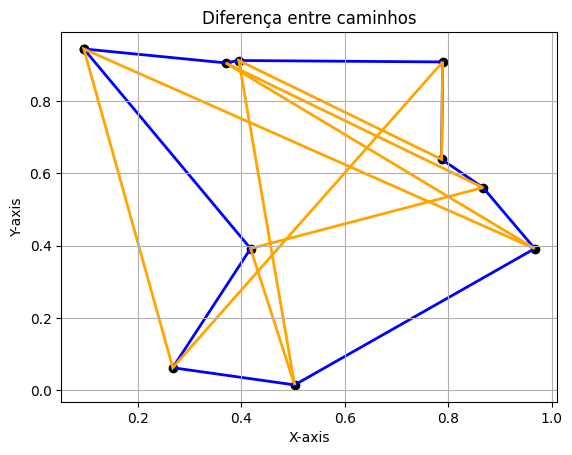

In [52]:
def testarSimulacaoAnnealing(
    quantidadeCidades: int = 10,
    temperatura: float = 10,
    passoReducao: float = 0.99,
    temperaturaMinima: float = 0.001
) -> None:
  (posicoesX, posicoesY) = criarVetorCidades(quantidadeCidades)

  resultado = aplicarSimulacaoAnnealing(
    posicoesX,
    posicoesY,
    temperatura = temperatura,
    passoReducao = passoReducao,
    temperaturaMinima = temperaturaMinima
  )

  print(f"[LOG]: Simulação com parâmetros - Cidades: {quantidadeCidades} Temperatura: {temperatura}")
  print("Melhor Caminho: ", resultado["melhorCaminho"])
  print("Melhor Custo: ", resultado["melhorCusto"])
  print("Custo Inicial: ", resultado["custoInicial"])

  plotCaminho(
    resultado["melhorCaminho"],
    posicoesX,
    posicoesY,
    titulo = "Melhor Caminho"
  )

  plotCaminho(
    resultado["caminhoInicial"],
    posicoesX,
    posicoesY,
    titulo = "Caminho Inicial"
  )

  plotTrocaCaminho(
    resultado["melhorCaminho"],
    resultado["caminhoInicial"],
    posicoesX,
    posicoesY,
    titulo = "Diferença entre caminhos"
  )

testarSimulacaoAnnealing()

Realizando uma simulação para um número de cidades maior, é possível notar que a diferença torna-se ainda mais gritante.


[LOG]: Simulação com parâmetros - Cidades: 150 Temperatura: 1000
Melhor Caminho:  [ 90 135  42 143 107 110  14 122 147  40  15  50 138   1  62   7  23   8
  83 106  24  79  70  39  26 118  68  54  87  11  69 111  58  18  55 113
 119  47  46  17   6  88  84 126  95  89  91 112  16 124 145 125  27   4
  53 114  98  13 121  34  28 140 123 139   3  56 105  75  74  71  78  77
  72 116 103 132  80  66 115  76  45  57  32  97 117  38 108  92 142  20
 102 130  65   0  36  35 104  44   9 101 141  94  29  41  49 137   2  37
  43  33  51  73  22  67 144 129  86  25  12 133  10  21  60  81 128 149
  85  61  64  31 100  96  48  93 127  82  30 120 148 136  99   5 131  19
  59 134 109  52 146  63]
Melhor Custo:  10.311073459676267
Custo Inicial:  83.8411572099697


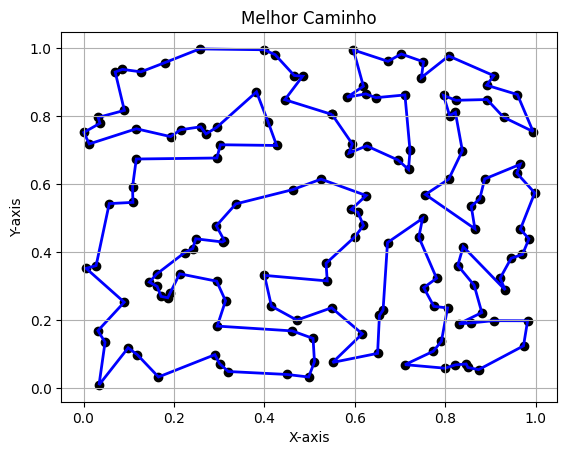

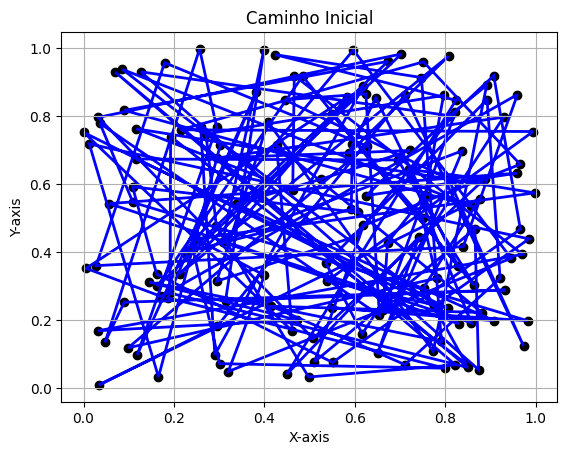

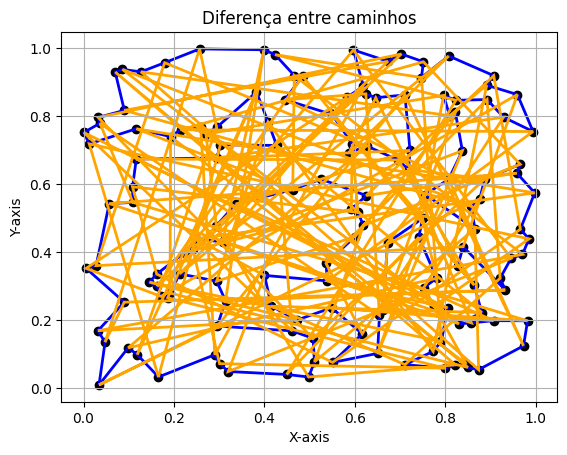

In [53]:
testarSimulacaoAnnealing(
    quantidadeCidades = 150,
    temperatura = 1000,
    passoReducao = 0.99,
    temperaturaMinima = 0.001
)

## Simulações
---

Agora iremos realizar simulações para alternando entre uma temperatura alta e outra baixa para diferentes quantidades de cidades.

In [101]:
TEMPERATURA_ALTA: float = 1500
TEMPERATURA_BAIXA: float = 5

PASSO_REDUCAO: float = 0.99
TEMPERATURA_MINIMA: float = 0.001

In [102]:
def GerarResultados(
    posicoesX: list[float],
    posicoesY: list[float],
    temperatura: float,
    passoReducao: float,
    temperaturaMinima: float
  ) -> None:

  resultado = aplicarSimulacaoAnnealing(
    posicoesX,
    posicoesY,
    temperatura = temperatura,
    passoReducao = passoReducao,
    temperaturaMinima = temperaturaMinima
  )

  print(f"[LOG]: Simulação com parâmetros - Cidades: {len(posicoesX)} Temperatura: {temperatura}")
  print("Melhor Caminho: ", resultado["melhorCaminho"])
  print("Melhor Custo: ", resultado["melhorCusto"])
  print("Custo Inicial: ", resultado["custoInicial"])

  plotCaminho(
    resultado["melhorCaminho"],
    posicoesX,
    posicoesY,
    titulo = "Melhor Caminho"
  )

### Teste de temperatura alta vs. baixa
---

[LOG]: Simulação com parâmetros - Cidades: 10 Temperatura: 1500
Melhor Caminho:  [8 9 3 0 1 6 2 5 4 7]
Melhor Custo:  2.5785596075164725
Custo Inicial:  6.5673135493007715


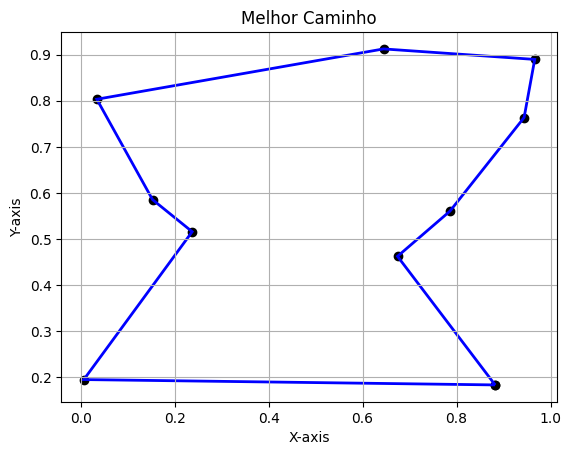

In [121]:
(posicoesX, posicoesY) = criarVetorCidades(10)
GerarResultados(
    posicoesX,
    posicoesY,
    temperatura = TEMPERATURA_ALTA,
    passoReducao = PASSO_REDUCAO,
    temperaturaMinima = TEMPERATURA_MINIMA
)

[LOG]: Simulação com parâmetros - Cidades: 10 Temperatura: 5
Melhor Caminho:  [8 9 3 0 1 6 2 5 4 7]
Melhor Custo:  2.5785596075164725
Custo Inicial:  5.211001067921831


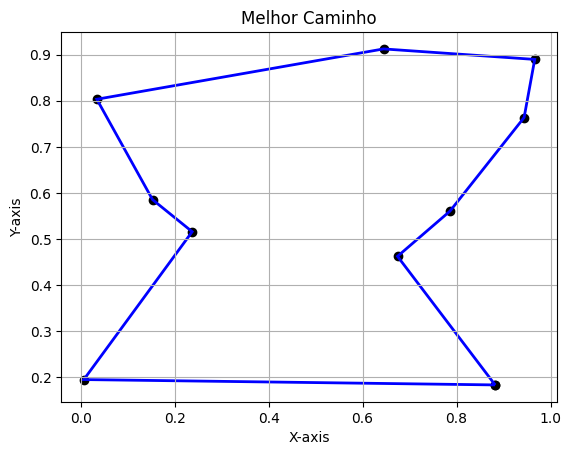

In [122]:
GerarResultados(
    posicoesX,
    posicoesY,
    temperatura = TEMPERATURA_BAIXA,
    passoReducao = PASSO_REDUCAO,
    temperaturaMinima = TEMPERATURA_MINIMA
)

[LOG]: Simulação com parâmetros - Cidades: 30 Temperatura: 1500
Melhor Caminho:  [22 13 10 19 27  4 26 16 28 23 11 12  2 29 15  5 24  8 25  7  1 20 21  9
 14  3  0  6 17 18]
Melhor Custo:  4.264359954766454
Custo Inicial:  14.77793776550345


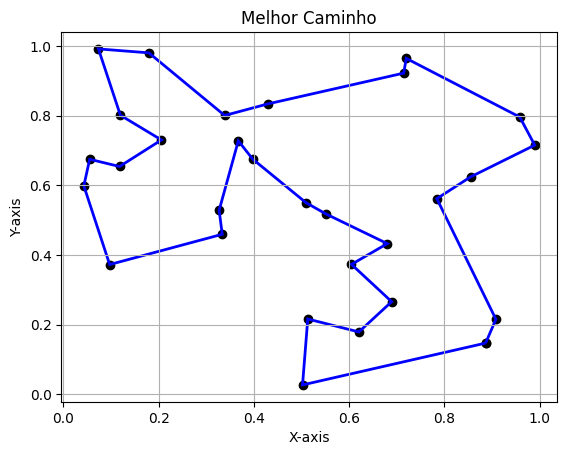

In [105]:
(posicoesX, posicoesY) = criarVetorCidades(30)
GerarResultados(
    posicoesX,
    posicoesY,
    temperatura = TEMPERATURA_ALTA,
    passoReducao = PASSO_REDUCAO,
    temperaturaMinima = TEMPERATURA_MINIMA
)

[LOG]: Simulação com parâmetros - Cidades: 30 Temperatura: 5
Melhor Caminho:  [ 9 21 20  7 25  8 24  5 15  2 12 11 29 23  1 28 16 26  4 27 19 10 14  3
  0 13 22  6 18 17]
Melhor Custo:  4.45412988638197
Custo Inicial:  13.784581614840862


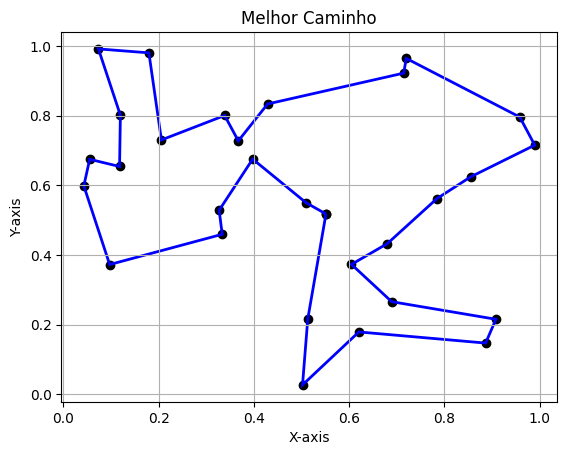

In [106]:
GerarResultados(
    posicoesX,
    posicoesY,
    temperatura = TEMPERATURA_BAIXA,
    passoReducao = PASSO_REDUCAO,
    temperaturaMinima = TEMPERATURA_MINIMA
)

[LOG]: Simulação com parâmetros - Cidades: 50 Temperatura: 1500
Melhor Caminho:  [41 47 10 15 37  0 36 42 30 34 23 29 38 43  6 14  7 27  9 45 18 25 19 49
 12 44 40 32 39  3 11 20 46 26 24 31 22 21 17 13  8  4  2 48  5 28 35  1
 16 33]
Melhor Custo:  5.860606906227463
Custo Inicial:  27.52146981447104


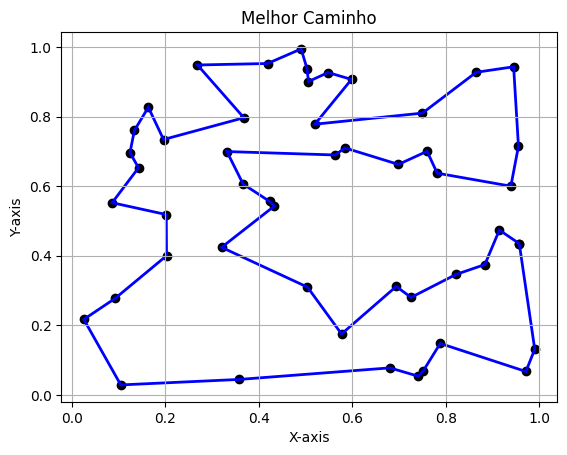

In [107]:
(posicoesX, posicoesY) = criarVetorCidades(50)
GerarResultados(
    posicoesX,
    posicoesY,
    temperatura = TEMPERATURA_ALTA,
    passoReducao = PASSO_REDUCAO,
    temperaturaMinima = TEMPERATURA_MINIMA
)

[LOG]: Simulação com parâmetros - Cidades: 50 Temperatura: 5
Melhor Caminho:  [ 2  4  8 13 30 42 34 23 29 38 20 46 17 21 22 31 24 26 11  3 39 32 40 44
 12 49 43  6 14  7 19 25 18 45 27  9 47 41 10 15 33 16 35 28  5  1 37  0
 36 48]
Melhor Custo:  5.902329206845865
Custo Inicial:  28.37569313305211


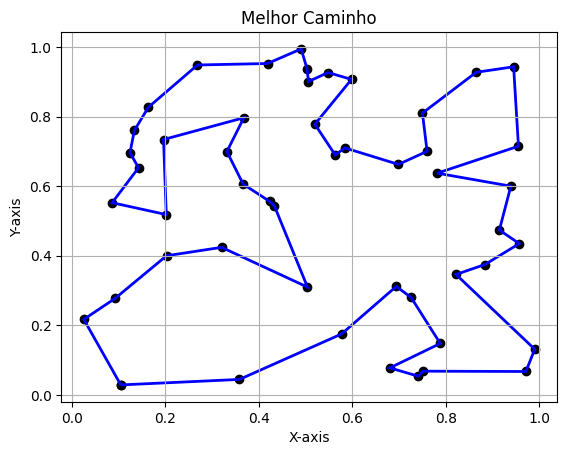

In [108]:
GerarResultados(
    posicoesX,
    posicoesY,
    temperatura = TEMPERATURA_BAIXA,
    passoReducao = PASSO_REDUCAO,
    temperaturaMinima = TEMPERATURA_MINIMA
)

In [124]:
(posicoesX, posicoesY) = criarVetorCidades(100)

[LOG]: Simulação com parâmetros - Cidades: 100 Temperatura: 1500
Melhor Caminho:  [17 98 74 63 10  5 27 66 53 97 64 12 45 80 93 77 90 36 50  1 99 47 48 96
 78 72 92 40 82 43 54 26  8 44 51 39 55 22 19 58 37 89 70 76 16 52 88  9
 29 79  0 49 14 30 20 84 15 32 56 33  3 91 68 31 62 86 11 21 87 24 18 71
 42 25  6 57 23  2 81 83 95 94 35 46 67 73 85  4 28 69 38 34 13 75 65 41
 61 60 59  7]
Melhor Custo:  8.441809157521115
Custo Inicial:  49.58539306108861


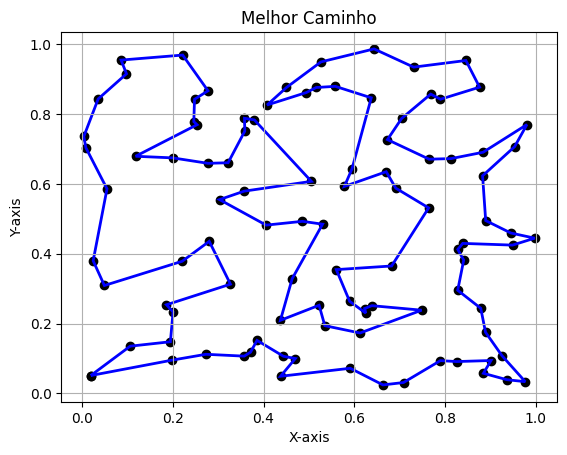

In [127]:
GerarResultados(
    posicoesX,
    posicoesY,
    temperatura = TEMPERATURA_ALTA,
    passoReducao = PASSO_REDUCAO,
    temperaturaMinima = TEMPERATURA_MINIMA
)

[LOG]: Simulação com parâmetros - Cidades: 100 Temperatura: 5
Melhor Caminho:  [32 56 49 86 62 68 31 33  3 91 24 18 87 21 11  9 88 71 42 25  6 57 23  2
 81 83 95 94 35 46 67 73 85  4 28 69 38 34 19 58 37 70 89 76 22 39 75 13
 65 41 61 60 59  7 17 98 74 63 10  5 51 55 16 52 44  8 79 29  0 82 26 43
 78 96 48 54 27 66 53 97 64 47 12 45 80 93 77 90 36 50  1 99 72 92 40 84
 15 20 30 14]
Melhor Custo:  8.47932274507177
Custo Inicial:  51.955481713869524


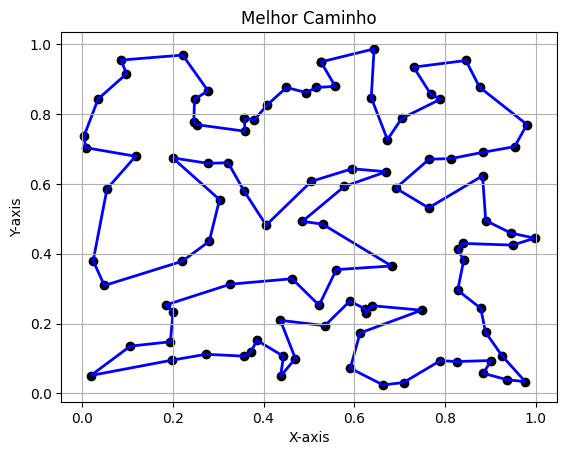

In [128]:
GerarResultados(
    posicoesX,
    posicoesY,
    temperatura = TEMPERATURA_BAIXA,
    passoReducao = PASSO_REDUCAO,
    temperaturaMinima = TEMPERATURA_MINIMA
)

In [129]:
(posicoesX, posicoesY) = criarVetorCidades(250)

[LOG]: Simulação com parâmetros - Cidades: 250 Temperatura: 1500
Melhor Caminho:  [ 47  32  93 126 140 167 217 210   8 221 238   0 162 194  30 187 117  55
 173 105 123 230  24  41 213  56  82  23  70  66  19 149  78  80 197 248
  40 215 113 141   5 152  90  79 142 196  91 216  53  20  50 136 186 212
 163 189 169 159 108 146 115 193  72  36 155 211 110  14 172 165 157  13
 203   4 198  33  61 227 179  52 249 130 171 228 220 182 181  86 121  44
  39 208  45  54  22  87  27 240 128 104 237   6  49  85 192 206  31 129
 191  59   3 176 170  81 229 124  29 120 201  62  71 127  60 103 209  11
  92  48 218  64  28  84  94 233 151 156  67 122 144 178 145 160  26 223
  16 242 183 101 131 139 164 190  63 174  38 132 111  73 243 150 125 106
 204  12 246 116 247 137  57  96 119 118 231 226  97 102  83 239   9 202
  88  18 241   7  69 107 222  34  37 214 177 205 185  65 134 175  21 158
 161 234  17 245  95 100 225  68 135 154 235 168  42  99 133 195  74 200
 114  77 166 184 147  76 109  43  46  98  

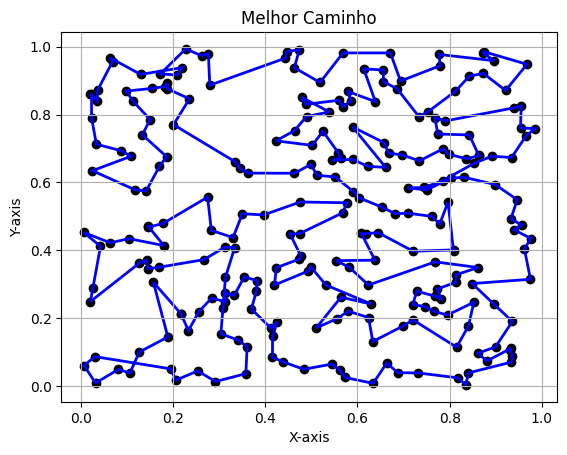

In [130]:
GerarResultados(
    posicoesX,
    posicoesY,
    temperatura = TEMPERATURA_ALTA,
    passoReducao = PASSO_REDUCAO,
    temperaturaMinima = TEMPERATURA_MINIMA
)

[LOG]: Simulação com parâmetros - Cidades: 250 Temperatura: 5
Melhor Caminho:  [230  24 123 173 105  55 117 187  30 153 236  15  58 207  35 138 148  75
 112   1  25  10  89  46  43 109  76 147 184  98   2 224 244 143 166 114
  77 200  67 156 151  94 233 178 131 145  84  28  48  92 218  64 209  11
  26 160 223 103  71 242  16 183 101  29 127  60  62 201 120 170 124 229
  81   3 176 182 181 228  52 220 121  86  39  44 208  87  22  54  45  59
 191  31  85 192  49 206 237 129 104 128 240  27 115 146 193  72 108   6
 159 169 163 189 212 186 155  36 211 136 142  79  90 152 113 215 141   5
 196  91 110  14 172 165  13 203 157  53  20 216  50  12 204 106 125 150
 243  73   4 198  33 227 179  61 249 171 130 190 164 139 144 122  74  99
 195 133 219 188 199 232 210   8 126 167 217 140  51  93  47  32 180 194
 162   0 238 221 245  95 225 100  42  68 135 154 235 111 132  38 174  63
 168  96  57 137 247  97 116 246 102   9 202 239  83  40 222 248 197  34
  78  80  19  66  70  23 149  82  56 213  41 

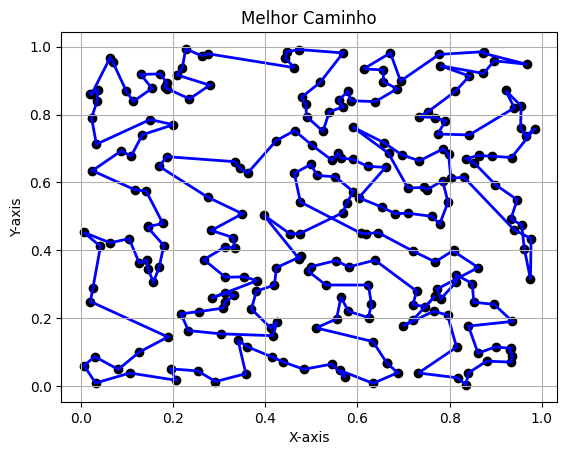

In [131]:
GerarResultados(
    posicoesX,
    posicoesY,
    temperatura = TEMPERATURA_BAIXA,
    passoReducao = PASSO_REDUCAO,
    temperaturaMinima = TEMPERATURA_MINIMA
)

## Gráficos de Custo
---


In [115]:
def GerarGraficoCusto(
    posicoesX: list[float],
    posicoesY: list[float],
    temperatura: float,
    passoReducao: float,
    temperaturaMinima: float
  ) -> None:

  resultado = aplicarSimulacaoAnnealing(
    posicoesX,
    posicoesY,
    temperatura = temperatura,
    passoReducao = passoReducao,
    temperaturaMinima = temperaturaMinima
  )

  plotCaminho(
    resultado["melhorCaminho"],
    posicoesX,
    posicoesY,
    titulo = "Melhor Caminho"
  )

  fig, ax = plt.subplots(2, 1, figsize=(10, 10))
  ax[0].plot(resultado["custos"])
  ax[0].set_xlabel("Quantidade de Passos")
  ax[0].set_ylabel("Custo")
  ax[0].set_title("Custo x Quantidade de Passos")

  ax[1].plot(resultado["temperaturas"])
  ax[1].set_xlabel("Quantidade de Passos")
  ax[1].set_ylabel("Temperatura")
  ax[1].set_title("Custo x Quantidade de Passos")
  plt.show()

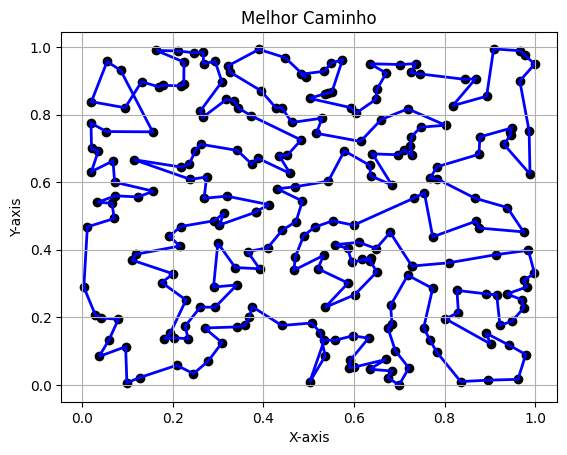

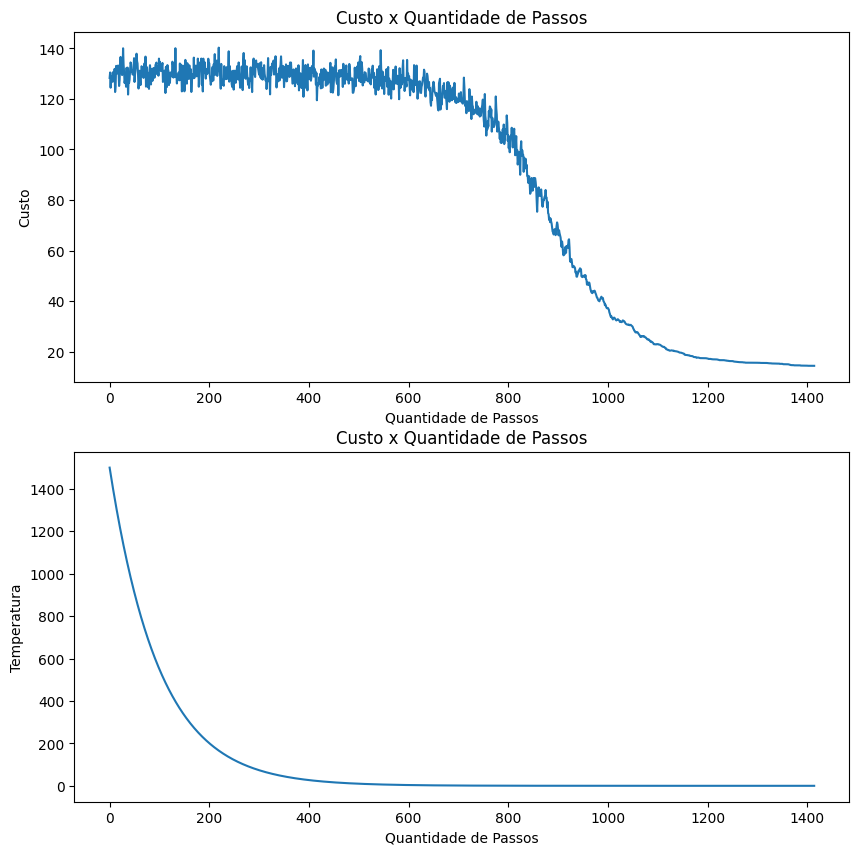

In [116]:
(posicoesX, posicoesY) = criarVetorCidades(250)

GerarGraficoCusto(
    posicoesX,
    posicoesY,
    temperatura = TEMPERATURA_ALTA,
    passoReducao = PASSO_REDUCAO,
    temperaturaMinima = TEMPERATURA_MINIMA
)

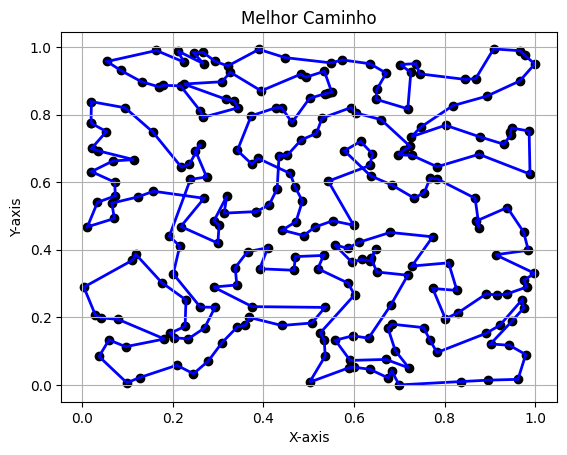

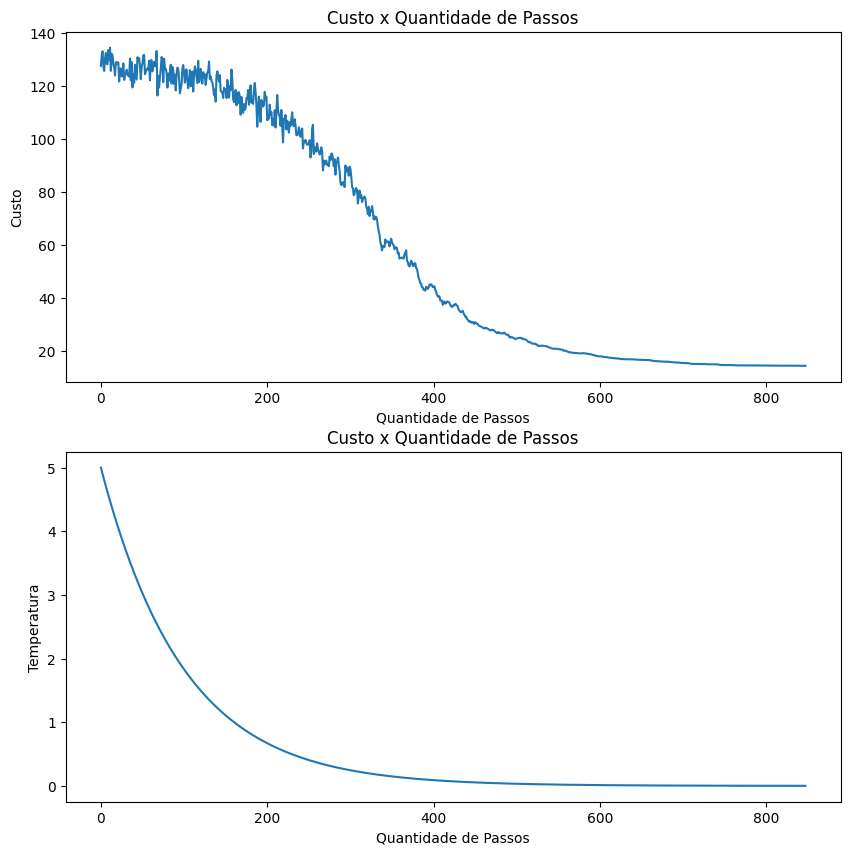

In [117]:
GerarGraficoCusto(
    posicoesX,
    posicoesY,
    temperatura = TEMPERATURA_BAIXA,
    passoReducao = PASSO_REDUCAO,
    temperaturaMinima = TEMPERATURA_MINIMA
)

## Análise dos Resultados
---

Primeiramente, é possível notar que os caminhos originais tendem a ter muitos cruzamentos e sobreposições de caminhos. Enquanto que os caminhos otimizados pelo processo de Annealing tendem a ser um polígono, sem nenhum cruzamento entre estradas.

Outro fator interessante é quando estamos trabalhando com a diferença de temperaturas. Para sistemas pequenos, com poucas cidades, os resultados entre baixa e alta temperatura tendem a ser mais próximos.

Por outro lado, a diferença entre usar ambas, tende a aumentar quando temos uma quantidade maior de cidades. Nesta situação, para temperaturas maiores, é mais comum se aproximar do resultado ótimo que quando estamos tratando de temperaturas baixas. Em outras palavras, conseguimos chegar a um mínimo mais próximo do global quando iniciamos com temperaturas maiores.

Acreditamos que a temperatura alta fornece mais energia, que possibilita que mais passos de Monte Carlo sejam feitos, aproximando cada vez mais da solução ótima, como é possível notar nos gráficos de custo.